# 1. 인물모드와 배경합성

DeepLabV3 모델을 사용하여 이미지에서 특정 객체(고양이, 사람 등)를 분리하고, 아웃포커싱(흐리게) 효과와 크로마키(배경 합성) 효과를 적용하는 기본 실습입니다.

In [24]:
import cv2                            # 이미지 파일을 읽고 다루기 위한 거대한 공구 상자 (OpenCV)입니다.
import numpy as np                    # 이미지를 픽셀 단위로 쉽게 계산하고 쪼개기 위한 수학 라이브러리입니다.
import os                             # 내 컴퓨터의 파잂 폴더나 경로들을 확인하기 위해 필요합니다.
from matplotlib import pyplot as plt  # 처리된 이미지를 주피터 노트북 화면에 예쁘게 띄워주는 도화지 역할을 합니다.
import torch                          # 딥러닝 뇌 구조(파이토치)를 사용하기 위해 가장 뼈대가 되는 라이브러리입니다.
from torchvision import transforms as T # 사진의 크기를 줄이거나, 색상을 딥러닝이 좋아하는 숫자로 바꿔주는 전처리 필터입니다.
from torchvision.models.segmentation import deeplabv3_resnet101 # 우리가 사용할 '사진 속 사물 맞추기' 모델(DeepLab)을 가져옵니다.

In [25]:
bg_path = 'sand.jpg'  # 나중에 사람을 오려내고 그 뒤에 깔아줄 새로운 배경 사진(모래사장)의 이름입니다.
img_bg_orig = cv2.imread(bg_path) # OpenCV 도구를 써서 모래사장 사진을 파이썬 메모리로 읽어옵니다.

if img_bg_orig is None: # 만약 사진 이름을 잘못 적었거나 없으면 경고문구를 띄워줍니다!
    print("배경 이미지를 찾을 수 없습니다. 경로를 확인해주세요.")

In [26]:
print("사전 학습된 DeepLabV3 모델을 로딩합니다...")
# DeepLab 모델을 가져오고, 학습은 끝났으니 '평가만 하겠다(.eval())'고 지시를 내립니다.
model = deeplabv3_resnet101(pretrained=True).eval()

# 사람이 보는 사진을 모델이 이해할 수 있는 수학적 숫자 덩어리(Tensor)로 가공하는 과정입니다.
transform = T.Compose([ 
    T.ToPILImage(),        # 컴퓨터용 배열(Numpy)을 눈으로 보는 진짜 이미지로 바꿉니다.
    T.Resize((520, 520)),  # 가로세로 520픽셀로 크기를 강제 고정합니다.
    T.ToTensor(),          # 이미지를 0~1 사이의 숫자 뭉텅이인 텐서(Tensor)로 바꿉니다.
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # 사진의 밝기와 대비를 규격에 맞게 표준화(평준화)시킵니다.
])

사전 학습된 DeepLabV3 모델을 로딩합니다...


C:\Users\Hwang\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Hwang\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



  정상 원본 파일: cat.jpg 처리 및 아웃포커싱/크로마키 적용


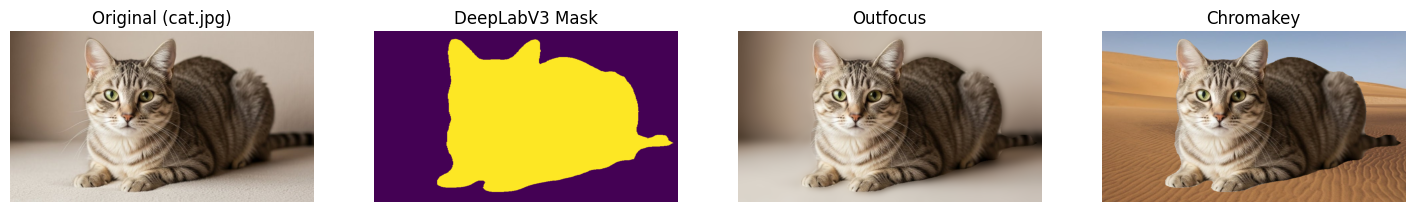


  정상 원본 파일: expo.jpg 처리 및 아웃포커싱/크로마키 적용


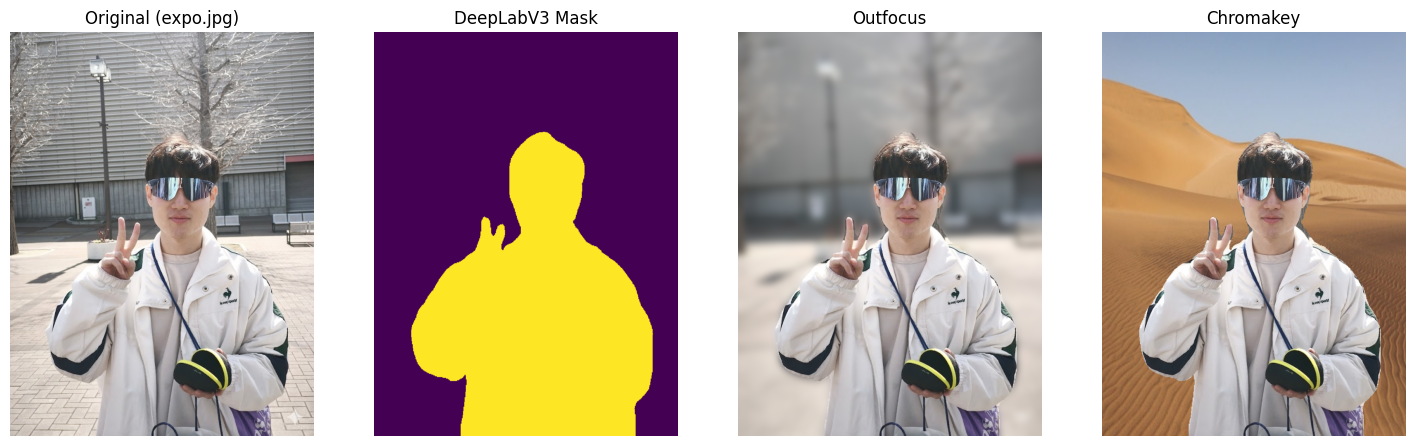

In [27]:
img_files_normal = ['cat.jpg', 'expo.jpg'] # 고양이 사진과 정상적인 사람 엑스포 사진 2개를 목록에 담습니다.

# 목록 안의 사진들을 하나씩 꺼내면서 반복 작업(for)을 시작합니다.
for img_file in img_files_normal:
    print(f"\n{'='*50}")
    print(f"  정상 원본 파일: {img_file} 처리 및 아웃포커싱/크로마키 적용")
    print(f"{'='*50}")
    
    img_orig = cv2.imread(img_file) # 파이썬 안으로 사진을 읽어 들입니다.
    if img_orig is None: continue   # 사진이 없으면 멈추지 말고 다음 사진으로 조용히 넘어갑니다.

    # 파이썬(OpenCV)은 색을 파랑-초록-빨강(BGR) 순서로 읽어서, 우리가 아는 빨강-초록-파랑(RGB)으로 순서를 다시 맞춰준 뒤 위에서 만든 전처리기(transform)에 넣습니다.
    input_tensor = transform(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)
    
    with torch.no_grad(): # AI에게 "우리는 평가만 할 거니까 새로 학습한다고 메모리 낭비하지 마!" 라고 지시합니다.
        output = model(input_tensor)["out"][0] # 모델에게 수학 숫자가 된 사진을 던져주고 결과물(이게 고양이일까 사람일까?)을 받아옵니다.
        output_predictions = output.argmax(0).byte().cpu().numpy() # 모델이 가장 확신하는 물체 번호표를 픽셀별로 뽑아냅니다.
    
    # 모델을 통과하며 520x520으로 찌그러졌던 결과 스티커를 원래 사진의 빵빵한 원본 크기로 쫙 늘려줍니다.
    output_predictions_resized = cv2.resize(output_predictions, 
                                            (img_orig.shape[1], img_orig.shape[0]), 
                                            interpolation=cv2.INTER_NEAREST)

    # 모델이 부여한 번호표(ID) 중에서: 고양이 사진이면 8번, 사람 사진이면 15번을 찾으라고 지시합니다.
    target_id = 8 if 'cat' in img_file else 15
    seg_map = (output_predictions_resized == target_id) # 우리가 찾던 번호와 일치하는 부분만 True(참), 나머지는 False(거짓)로 표시합니다.
    
    # True는 255(완전 흰색), False는 0(완전 검은색)인 예쁜 흑백 마스크 스티커로 만듭니다.
    img_mask = seg_map.astype(np.uint8) * 255
    img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR) # 흑백 마스크를 컬러 사진과 겹칠 수 있게 3장 카피(BGR)해줍니다.

    # img_mask_color가 255(흰색, 즉 사람/고양이)면 선명한 원본을 쓰고, 아니면 거칠게 흐려버린(블러 처리된) 영상(GaussianBlur)을 덮어씁니다.
    img_outfocus = np.where(img_mask_color == 255, img_orig, cv2.GaussianBlur(img_orig, (65, 65), 0))
    
    img_bg_resized = cv2.resize(img_bg_orig, (img_orig.shape[1], img_orig.shape[0])) # 뒤에 깔 모래사장 배경도 원본 크기에 맞게 쭉 늘립니다.
    # 사람(255)이면 그대로 사람을 쓰고, 남은 검은 배경에는 방금 늘린 모래사장 사진을 합성(크로마키)합니다.
    img_chromakey = np.where(img_mask_color == 255, img_orig, img_bg_resized)

    # 도화지를 넓게 펴고(18x6 크기), 원본 / 흑백마스크 / 배경흐림 / 배경합성 4장의 결과물을 예쁘게 나란히 출력합니다!
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 4, 1); plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)); plt.title(f"Original ({img_file})"); plt.axis('off')
    plt.subplot(1, 4, 2); plt.imshow(img_mask); plt.title("DeepLabV3 Mask"); plt.axis('off')
    plt.subplot(1, 4, 3); plt.imshow(cv2.cvtColor(img_outfocus, cv2.COLOR_BGR2RGB)); plt.title("Outfocus"); plt.axis('off')
    plt.subplot(1, 4, 4); plt.imshow(cv2.cvtColor(img_chromakey, cv2.COLOR_BGR2RGB)); plt.title("Chromakey"); plt.axis('off')
    plt.show()

--- 
# 2. 인물사진 문제점 생성

원본 엑스포 사진(`expo.jpg`) 뒤에 생성형 AI를 이용해 허구의 벤치 위에 걸린 '가짜 옷'을 그려 넣었습니다(`expo_fake.jpg`). 

우리 눈에는 뒤에 걸쳐진 물건이지만, 딥러닝 AI(DeepLab)는 **'픽셀의 색깔과 무늬'**로 대상을 유추합니다. 인물(피사체)이 입고 있는 패딩과 **거의 똑같은 질감과 색상**을 가진 함정이 생겼을 때, 픽셀 멍청이(DeepLabV3)가 얼마나 크게 무너지고 착각하는지 눈으로 먼저 확인해 봅니다.


  적대적 합성 파일: expo_fake.jpg 모델 오류 유발 테스트


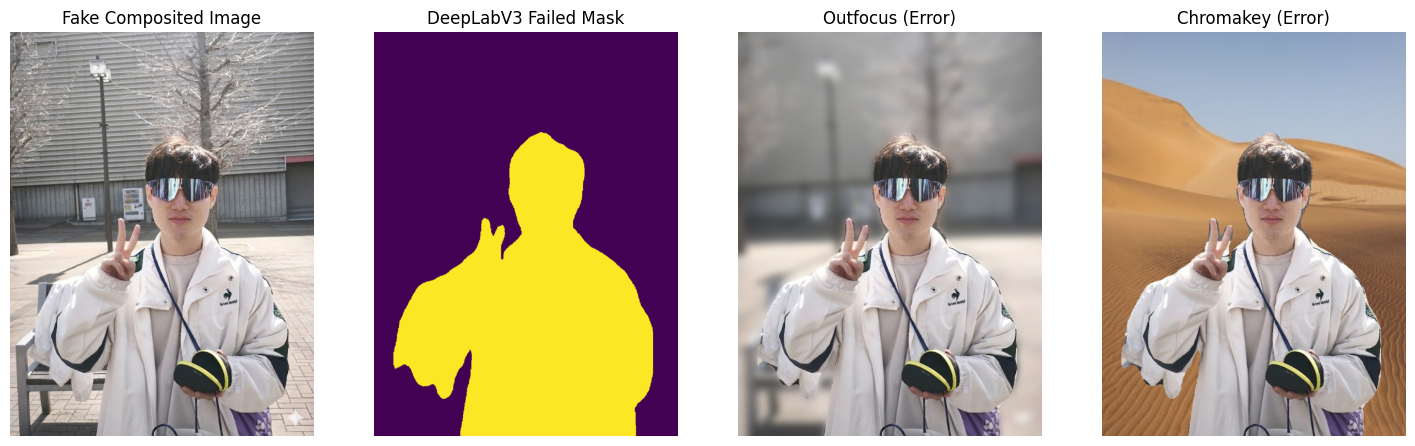

결과 해석: DeepLabV3는 인물 뒤에 합성된 똑같은 재질의 조각을 '사람 몸통'으로 속아 넘어가 마스킹 영역에 그대로 포함시켜 버렸습니다.


In [ ]:
img_file_fake = 'expo_fake.jpg' # 테스트용 가짜 합성 이미지
print(f"\n{'='*50}")
print(f"  적대적 합성 파일: {img_file_fake} 모델 오류 유발 테스트")
print(f"{'='*50}")

img_fake = cv2.imread(img_file_fake)
if img_fake is not None:
    # 1. 아까와 완전히 똑같은 DeepLab 모델에게 이 함정 카드를 던져줍니다.
    input_tensor = transform(cv2.cvtColor(img_fake, cv2.COLOR_BGR2RGB)).unsqueeze(0)
    with torch.no_grad():
        output = model(input_tensor)["out"][0]
        output_predictions = output.argmax(0).byte().cpu().numpy()
    
    # 2. 결과물 스티커를 다시 사람 눈 높이에 맞게 사진 원본 사이즈로 쭉 늘려줍니다.
    output_predictions_resized = cv2.resize(output_predictions, 
                                            (img_fake.shape[1], img_fake.shape[0]), 
                                            interpolation=cv2.INTER_NEAREST)

    # 3. 모델이 15번(사람)이라고 확신한 부분만 흰색(255)으로 오려내 마스크를 만듭니다.
    seg_map = (output_predictions_resized == 15)
    img_mask = seg_map.astype(np.uint8) * 255
    img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

    # 4. 아웃포커스와 크로마키(해변 배경) 합성을 수행합니다.
    img_outfocus = np.where(img_mask_color == 255, img_fake, cv2.GaussianBlur(img_fake, (65, 65), 0))
    img_bg_resized = cv2.resize(img_bg_orig, (img_fake.shape[1], img_fake.shape[0]))
    img_chromakey = np.where(img_mask_color == 255, img_fake, img_bg_resized)

    # 5. 어떻게 무너졌는지 결과를 그려봅니다.
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 4, 1); plt.imshow(cv2.cvtColor(img_fake, cv2.COLOR_BGR2RGB)); plt.title("Fake Composited Image"); plt.axis('off')
    plt.subplot(1, 4, 2); plt.imshow(img_mask); plt.title("DeepLabV3 Failed Mask"); plt.axis('off')
    plt.subplot(1, 4, 3); plt.imshow(cv2.cvtColor(img_outfocus, cv2.COLOR_BGR2RGB)); plt.title("Outfocus (Error)"); plt.axis('off')
    plt.subplot(1, 4, 4); plt.imshow(cv2.cvtColor(img_chromakey, cv2.COLOR_BGR2RGB)); plt.title("Chromakey (Error)"); plt.axis('off')
    plt.show()
    print("결과 해석: DeepLabV3는 인물 뒤에 합성된 똑같은 재질의 조각을 '사람 몸통'으로 속아 넘어가 마스킹 영역에 그대로 포함시켜 버림.")
else:
    print("합성 이미지를 찾을 수 없습니다.")

--- 
# 3. Semantic Segmentation의 한계와 개선 방안 (코드별 작동 원리 설명)

모델이 엉뚱하게 벤치 옷을 사람으로 속아 넘어갔을 때, 이를 엔지니어의 상상력과 논리로 돌파하려 했던 3가지 시도 스크립트입니다.

## 시도 1: Morphological Cut & GrabCut (형태학적 절단술)

**어떻게 작동하나요 (비전공자 설명):**
- **모폴로지(침식):** 마치 사과 껍질을 깎아내듯, 흑백 마스크의 테두리를 안쪽으로 왕창 파먹는 기술입니다. 사람과 벤치가 간신히 한 줄기로 이어져 있을 테니, 테두리를 깎아 먹다 보면 **그 연결고리가 툭 하고 부러져서 떨어져 나갈 것**이라고 기대하는 전략입니다.
- **GrabCut:** 색상을 아주 예민하게 찾아내는 고전 스킬입니다. 연결이 부러진 상태에서 마스크를 던져주어, "색상이 다른 배경을 다듬어서 깔끔하게 구분해 줘!"라고 부탁하는 이중 필터링입니다.

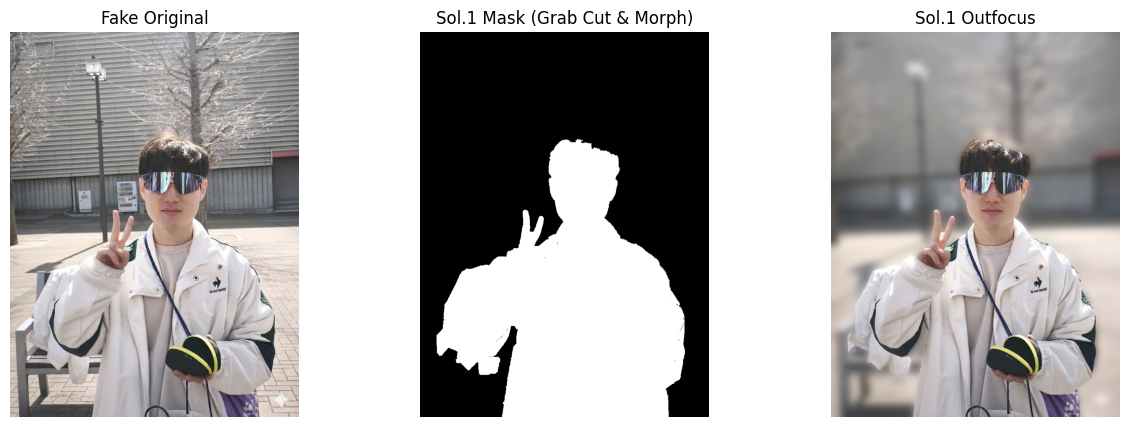

In [30]:
if img_fake is not None:
    # 1. 앞서 실패했던 DeepLabV3의 원본 흑백 마스크를 그대로 들고 옵니다.
    raw_mask = cv2.resize((output_predictions == 15).astype(np.uint8) * 255, (img_fake.shape[1], img_fake.shape[0]))
    
    # 2. 아주 크고 강력한 45픽셀 두께의 쇠기둥(Kernel)을 준비합니다.
    kernel_erosion = np.ones((45, 45), np.uint8)
    # 이 쇠기둥으로 하얀색 마스크(사람영역) 테두리를 안쪽으로 사정없이 갉아먹게(Erode) 합니다. 연결고리를 끊는 핵심입니다.
    eroded_mask = cv2.erode(raw_mask, kernel_erosion, iterations=1)
    
    # 3. GrabCut 알고리즘을 돕기 위해, 절대 건들지 말아야 할 '확실한 진짜 배경'을 지정합니다.
    dilated_mask = cv2.dilate(raw_mask, np.ones((10, 10), np.uint8), iterations=1)
    sure_bg = cv2.bitwise_not(dilated_mask) # 진짜 배경 부분만 하얗게 변환합니다.

    # 4. GrabCut이 이해할 수 있는 4단계 색칠 지도(0:배경, 1:절대전경, 2:아마도배경, 3:아마도전경)를 조립합니다.
    gc_mask = np.full(img_fake.shape[:2], 2, dtype=np.uint8)
    gc_mask[raw_mask == 255] = 3     # 딥랩이 잡은 곳은 3번(아마 옷이겠지?)
    gc_mask[eroded_mask == 255] = 1  # 침식 후에도 끝까지 살아남은 몸통뼈대는 1번(절대 사람이다!)
    gc_mask[sure_bg == 255] = 0      # 사람 밖 먼바다 우주는 0번(절대 배경이다!)
    
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    # 대망의 GrabCut 작동! 사진 원본과 우리가 준 힌트(gc_mask)를 보고 경계선을 미친 듯이 연산합니다.
    cv2.grabCut(img_fake, gc_mask, None, bgd_model, fgd_model, 10, cv2.GC_INIT_WITH_MASK)
    
    # GrabCut이 연산을 끝내면, 1번(절대 전경)과 3번(아마추정) 결과를 255(하얀색 마스크)로 돌려받습니다.
    temp_mask = np.where((gc_mask == 1) | (gc_mask == 3), 255, 0).astype(np.uint8)
    
    # 5. Connected Components (잔해 치우기): 모폴로지 톱질로 인해 잘려나간 자잘한 옷 조각들이 허공에 떠다닐 수 있습니다.
    # 화면에서 제일 큰 '본체 덩어리 1개'를 제외한 모든 자잘한 우주 쓰레기 파편을 지워버리는 수식입니다.
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(temp_mask)
    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        solution1_mask = (labels == largest_label).astype(np.uint8) * 255
    else:
        solution1_mask = temp_mask

    # 6. 배경을 흐리게 지워주고 결과를 출력합니다.
    mask_color = cv2.cvtColor(solution1_mask, cv2.COLOR_GRAY2BGR)
    img_outfocus = np.where(mask_color == 255, img_fake, cv2.GaussianBlur(img_fake, (65, 65), 0))
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(cv2.cvtColor(img_fake, cv2.COLOR_BGR2RGB)); plt.title("Fake Original"); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(solution1_mask, cmap='gray'); plt.title("Sol.1 Mask (Grab Cut & Morph)"); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(cv2.cvtColor(img_outfocus, cv2.COLOR_BGR2RGB)); plt.title("Sol.1 Outfocus"); plt.axis('off')
    plt.show()

## 시도 2: MiDaS 3D Depth Map (공간 심도/깊이 필터링)

**어떻게 작동하나요 (비전공자 설명):**
- **거리감(Depth) 측정:** 앞선 방법이 '색상'에만 눈이 멀어 수술하다 사람을 망쳤다면, 이번엔 MiDaS라는 입체 공간 스캐너 모델을 가져옵니다. 사진을 보고 물체가 카메라 렌즈에서 얼마나 멀리 떨어져 있는지 계산합니다.
- **논리 전개:** "옷 색깔이 달라도 상관없다. 저렇게 등 뒤에 벤치에 걸려 있는 사물이라면, 사람의 가슴팍(거리 1번지)보다 한참 뒤(거리 5번지)에 위치할 것이다. 고로 심도(깊이) 수치값만 가지고 뒷배경을 잘라내 보자!"라는 참신한 시도입니다.

Using cache found in C:\Users\Hwang/.cache\torch\hub\intel-isl_MiDaS_master


Loading weights:  None


Using cache found in C:\Users\Hwang/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master
Using cache found in C:\Users\Hwang/.cache\torch\hub\intel-isl_MiDaS_master


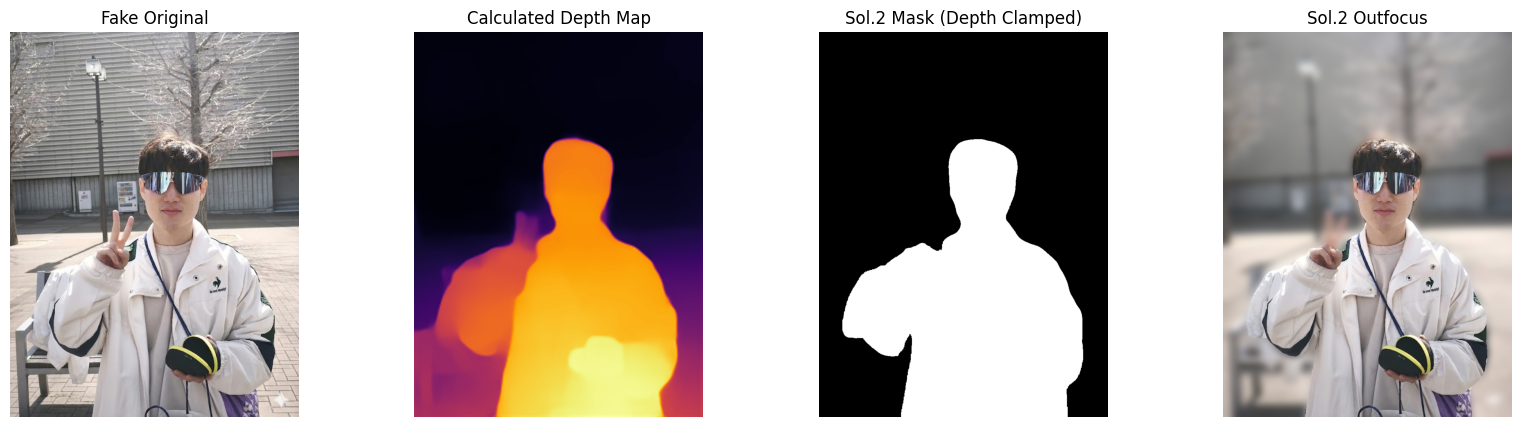

In [31]:
if img_fake is not None:
    # 1. 인텔(Intel)이 만든 강력한 3D 거리 측정 AI(MiDaS)를 클라우드에서 바로 다운받아 실행 모드로 켭니다.
    midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small").eval()
    # 2. 이 모델이 사진을 잘 볼 수 있게 축소시켜주는 마법 전처리기를 들고 옵니다.
    midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
    depth_transform = midas_transforms.small_transform
    
    # 사진 색깔 세팅을 맞추고, 전처리기에 통과시킵니다.
    img_rgb = cv2.cvtColor(img_fake, cv2.COLOR_BGR2RGB)
    depth_input = depth_transform(img_rgb)
    
    with torch.no_grad():
        # 3. 모델에 사진을 넣으면 거리감 수치 결과(수학적 행렬)가 툭 튀어나옵니다.
        depth_prediction = midas(depth_input)
        # 아까 쪼그라들었던 사이즈를 다시 원본 사진 폭과 높이에 맞게 부드럽게 땡겨주어 해상도를 복원합니다.
        depth_prediction = torch.nn.functional.interpolate(
            depth_prediction.unsqueeze(1),
            size=img_fake.shape[:2],
            mode="bicubic",
            align_corners=False,
        ).squeeze().cpu().numpy()
        
    # 4. 보기 지저분한 복잡한 소수점 수치들을 사람이 보기 좋은 0~255 숫자(흑백 픽셀)로 깔끔하게 정리해줍니다.
    depth_norm = cv2.normalize(depth_prediction, None, 0, 255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    
    depth_threshold = 80 # 심도 커트라인
    
    # 5. 기존 DeepLab 마스크(사람영역 전체) 중에서, 픽셀마다 매겨진 거리값을 추려냅니다.
    person_depths = depth_norm[raw_mask == 255]
    if len(person_depths) > 0:
        # 사람 몸통의 '평균적인 뱃살 거리'의 중간점(median)을 찾습니다.
        median_depth = np.median(person_depths)
        
        # [결정적 컷팅] 사람 몸통(median) 기준에서 80만큼이나 더 뒤로 물러나 깊이 박혀있는 대상은 배경이겠지? 하고 모조리 0(흑백)으로 날려버립니다.
        solution2_mask = np.where((raw_mask == 255) & (depth_norm >= median_depth - depth_threshold), 255, 0).astype(np.uint8)
    else:
        solution2_mask = raw_mask
        
    # 결과를 흐리게 지워주고 출력합니다.
    mask_color = cv2.cvtColor(solution2_mask, cv2.COLOR_GRAY2BGR)
    img_outfocus = np.where(mask_color == 255, img_fake, cv2.GaussianBlur(img_fake, (65, 65), 0))
    
    # 4번 카드로 사진 원본, 뎁스맵 열화상 컬러, 수술당한 마스크, 최종 효과를 예쁘게 나열합니다.
    plt.figure(figsize=(20, 5))
    plt.subplot(1, 4, 1); plt.imshow(cv2.cvtColor(img_fake, cv2.COLOR_BGR2RGB)); plt.title("Fake Original"); plt.axis('off')
    # 뎁스맵은 카메라에 가까우면 노랗고, 멀어지면 어두운 열화상 카메라 색상(inferno)으로 보여줍니다!
    plt.subplot(1, 4, 2); plt.imshow(depth_norm, cmap='inferno'); plt.title("Calculated Depth Map"); plt.axis('off')
    plt.subplot(1, 4, 3); plt.imshow(solution2_mask, cmap='gray'); plt.title("Sol.2 Mask (Depth Clamped)"); plt.axis('off')
    plt.subplot(1, 4, 4); plt.imshow(cv2.cvtColor(img_outfocus, cv2.COLOR_BGR2RGB)); plt.title("Sol.2 Outfocus"); plt.axis('off')
    plt.show()

## 시도 3: Body-Topology 모델 + 수동 공간 분할(Spatial Cut) (최종 결과)

**어떻게 작동하나요 (비전공자 설명):**
- **인체 뼈대 스캐너 (MediaPipe):** 구글이 스마트폰용으로 개발한 압도적인 기술입니다. 이 모델은 사진 속에서 픽셀이나 색 지도를 보지 않습니다. 오직 '어깨관절, 팔꿈치, 코, V자 모양을 한 손가락 관절망' 수십만 개를 달달 암기하여 **'진짜 인간의 뼈 모양'**을 본뜬 후, 그 뼈대에 해당하는 영역의 표면적만 마스킹을 떠냅니다. 색깔 속임수가 아예 통하지 않습니다.
- **기형의 파괴 (공간 분할 수술):** 구글의 기술력으로도 벤치 옷걸이 일부를 '접힌 펑퍼짐한 소매 끝단'으로 착각하는 오류가 났습니다. 이를 없애기 위해 **사진을 가로 기준으로 위아래 두 동강 분할**해 버립니다. V자 손가락이 있는 얼굴 구역(위 65%)은 절대로 터치하지 않고 놔두되, 문제가 발생한 하단 구역(허리 밑 35%)에만 강제로 거대한 모종삽(모폴로지 대패)을 들이박아 혹을 파내고 두꺼운 원본 팔뚝만 재생시키는 극단적인 수동 컨트롤을 섞었습니다.

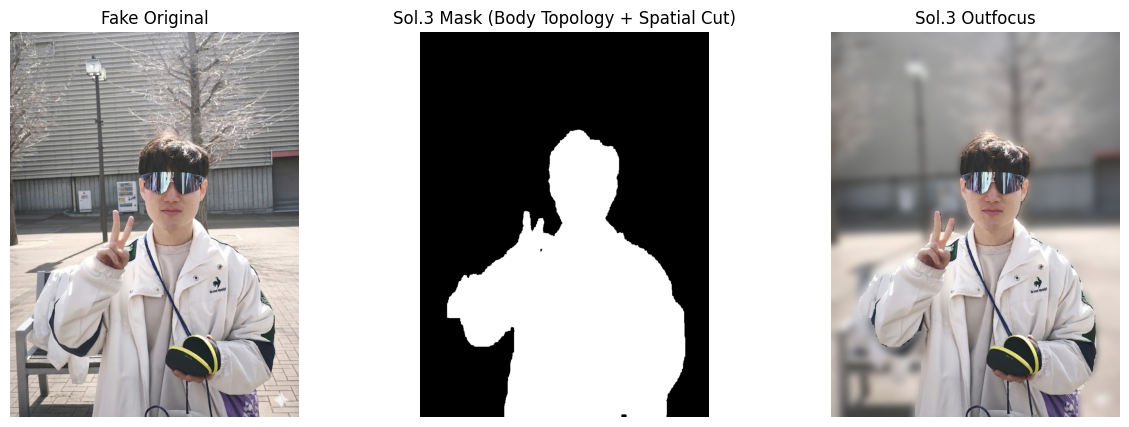

In [32]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request

if img_fake is not None:
    # 1. 최고 최신 인체 구조(뼈대)망 인식 두뇌 파일(tflite)을 구글 저장소에서 모셔옵니다.
    model_path = "selfie_segmenter.tflite"
    if not os.path.exists(model_path):
        urllib.request.urlretrieve("https://storage.googleapis.com/mediapipe-models/image_segmenter/selfie_segmenter/float16/latest/selfie_segmenter.tflite", model_path)

    # 2. 다운받은 두뇌 파일을 바탕으로 MediaPipe의 작업 옵션을 켭니다.
    base_options = python.BaseOptions(model_asset_path=model_path)
    # output_confidence_masks: '저게 사람일 확률'이 담긴 정교한 흑백 지도를 달라고 요구하는 옵션입니다.
    options = vision.ImageSegmenterOptions(base_options=base_options, output_confidence_masks=True)

    # 3. 모델 안으로 사진을 집어넣어 처리(Segment)를 맡깁니다.
    with vision.ImageSegmenter.create_from_options(options) as segmenter:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(img_fake, cv2.COLOR_BGR2RGB))
        segmentation_result = segmenter.segment(mp_image)
        
        # 4. 모델이 뱉어낸 복잡한 3D 결과물을 np.squeeze()를 사용해 군더더기 없는 2D 흑백 판(H, W)으로 압착(Squeeze)시켜 가져옵니다.
        confidence_mask = np.squeeze(segmentation_result.confidence_masks[0].numpy_view())
        
        # 5. [신뢰도 상향 튜닝] 확률이 85% 이상(사람인 게 매우 유력)인 부분만 남기고, 긴가민가한 파편(0.85 이하)들은 전부 불합격 시켜버립니다.
        t_mask = (confidence_mask > 0.85).astype(np.uint8) * 255
        
        # 6. [공간 분할(Spatial Cut) 외과 수술 시작!]
        split_y = int(t_mask.shape[0] * 0.65) # 전체 세로 길이의 65% 지점. (예: 100cm라면 위에서부터 65cm 지점에 분필로 위아래 경계를 긋습니다)
        
        # 35픽셀 두께를 가진 거대한 칼날 블록을 만듭니다.
        # 이 블록으로 파먹었다가(침식) 재생(팽창)시키는 Opening 기술을 먹이면, 35픽셀보다 얇은 팔뚝 바깥의 쥐젖(돌연변이)은 복구되지 않고 영원히 사라지게 됩니다.
        opened_mask = cv2.morphologyEx(t_mask, cv2.MORPH_OPEN, np.ones((35, 35), np.uint8))
        
        solution3_mask = t_mask.copy() # 원본 수술 복제본을 상에 올립니다.
        # [수술의 클라이막스] 위 65%(얼굴과 V손가락)는 냅두고, 문제가 생긴 아래쪽 35% 공간 픽셀에만 방금 만든 거대한 대패질 수술 결과를 강제 덮어씌웁니다!
        solution3_mask[split_y:, :] = opened_mask[split_y:, :]
        
        # 7. 수술 상처 부위를 아물게 하기 위해 아주 미세한 연고(3x3)를 발라 마스크를 자연스럽게 1회 살짝 팽창시켜 줍니다.
        solution3_mask = cv2.dilate(solution3_mask, np.ones((3, 3), np.uint8), iterations=1)
        
    # 8. 대망의 결과 렌더링. 배경 흐림을 적용합니다.
    mask_color = cv2.cvtColor(solution3_mask, cv2.COLOR_GRAY2BGR)
    img_outfocus = np.where(mask_color == 255, img_fake, cv2.GaussianBlur(img_fake, (65, 65), 0))
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(cv2.cvtColor(img_fake, cv2.COLOR_BGR2RGB)); plt.title("Fake Original"); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(solution3_mask, cmap='gray'); plt.title("Sol.3 Mask (Body Topology + Spatial Cut)"); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(cv2.cvtColor(img_outfocus, cv2.COLOR_BGR2RGB)); plt.title("Sol.3 Outfocus"); plt.axis('off')
    plt.show()

---
# 4. 시나리오별 한계 분석 및 느낀점 (Conclusion)


### 🚨각 솔루션이 무너진 이유

**1. GrabCut (모폴로지 절단) 방법의 한계점 :**
- 인위적으로 그린 사진이라 실제 옷과 뒤에있는 옷이 마치 하나인것 처럼 연결되어 있어 모폴로지가 뒤에있는 옷까지 하나로 인식하고 테두리를 그림. 오리혀 머리카락을 주변 배경과 헷갈려서 갉아먹음    

**2. MiDaS 3D Depth Map (공간 필터링)의 실패 원인 (열화상 지도 색깔을 분석):**
- 마찬가지로 AI가 그린 그림이라 모델이 옷이 몸통과 같은 z좌표에 위치해 있다고 판단. 오히려 손가락 주변 픽셀이 배경이라 손가락이 멀리있는 물체라고 생각하고 손가락을 잘라버림  

**3. MediaPipe 기반 뼈대 추적망 + 수동 절단 수술의 결과 평가:**
- 팔꿈치 아래쪽은 성공적으로 도려냈지만 여전히 팔뚝 옆에 옷감이 마치 혹처럼 붙어있음. 수동 공간 분할(Spatial Cut) 자체가 이 사진만을 위한 전처리로 모델의 일반화 성능이 매우 떨어짐(과적합)

---

### 💡 솔루션을 진행하며 느낌점



1. **오버피팅(Overfitting)과 수동 코딩의 한계:** 화면의 특정 위치(y=65%)를 찍어 인위적으로 혹을 잘라내는 행위(Spatial Cut)는 오직 저 사진 한 장에만 통하는 방법으로 사진 한장의 문제를 해결하기위해 파라미터를 조정하는것은 일반화 성능을 아예 떨어뜨림. 저 사진 한장만 해결하는게 목적이면 포토샵으로 누끼따는게 훨씬


3. **데이터 주도성(Data-Centric AI)의 위력:** 색상(DeepLab), 깊이(MiDaS), 뼈대(MediaPipe) 등 서로 다른 지능의 잣대를 가진 다양한 모델을 사용했지만 사전학습된 모델들로는 ai가 마치 한몸인것 처럼 그린 그림을 구분하지 못함.
아무리 모폴로지 옵션을 1픽셀 단위로 깎으며 함수를 치고, 화려하고 복잡한 백엔드 모델을 구축하려 애써도, **"합성된 가짜 벤치 데이터 1,000장을 사람들에게 '이건 배경 옷걸이야'라고 태깅(Tagging) 시켜 다시 학습 투입하는 것"**이 훨씬 효율적인 문제 해결 방식임.

3. 이런 인위적인 합성이 아닌 실제로 벤치에 하얀옷을 걸어두고 같은 구도에서 사진을 찍었다면 위의 방법들로 해결 할 수 있었을지도 모른다고 생각함.